In [2]:
%pip install pandas matplotlib seaborn scipy statsmodels scikit-learn

Note: you may need to restart the kernel to use updated packages.


# Vitor Taranto DRE: 121063585

# Projeto Probest - Parte 1
## Fase 1: Análise Exploratória de Dados (EDA)

In [3]:
import pandas as pd
import numpy as np

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.options.display.float_format = '{:.6f}'.format

## 1. Carga e Verificação dos Dados

Carregamento do arquivo `ndt_tests_corrigido.csv` e verificação inicial da estrutura dos dados (colunas e primeiras linhas).

In [4]:
file_path = 'ndt_tests_corrigido.csv'

try:
    df = pd.read_csv(file_path)
    print(f"Dataset carregado: {file_path}")
    print(f"Formato: {df.shape}")
    
    print("\nColunas disponíveis:")
    print(df.columns.tolist())
    
    print("\nVerificando dados (primeiras linhas):")
    print(df.head())
    
except FileNotFoundError:
    print(f"ERRO: Arquivo não encontrado em '{file_path}'")
except Exception as e:
    print(f"Ocorreu um erro: {e}")

Dataset carregado: ndt_tests_corrigido.csv
Formato: (7087, 8)

Colunas disponíveis:
['timestamp', 'download_throughput_bps', 'rtt_download_sec', 'upload_throughput_bps', 'rtt_upload_sec', 'packet_loss_percent', 'client', 'server']

Verificando dados (primeiras linhas):
                       timestamp  download_throughput_bps  rtt_download_sec  upload_throughput_bps  rtt_upload_sec  packet_loss_percent    client    server
0  2025-08-09 15:28:02.000 +0000          82236567.995454          0.231862        69732172.059986        0.247727             0.000000  client12  server06
1  2025-08-09 15:30:11.000 +0000         902731479.238230          0.012000       852177960.399178        0.005423             0.008226  client01  server07
2  2025-08-10 04:27:43.000 +0000         591065502.098614          0.014000       281218794.113733        0.014544             5.954284  client13  server07
3  2025-08-09 22:45:07.000 +0000         672113910.536765          0.011000       113539960.296302        

## 2. Pré-processamento: Normalização da Fração de Perda

A coluna `packet_loss_percent` está em formato percentual (0-100). Para a modelagem (especialmente a Beta-Binomial), é necessário convertê-la para uma fração (proporção de 0 a 1). A célula seguinte cria a nova coluna `packet_loss_fraction`.

In [5]:
# Criar a coluna de fração de perda dividindo por 100
if 'packet_loss_percent' in df.columns:
    df['packet_loss_fraction'] = df['packet_loss_percent'] / 100
    print("Coluna 'packet_loss_fraction' criada.")
    
    # Verificar a nova coluna
    print(df[['packet_loss_percent', 'packet_loss_fraction']].head())
else:
    print("AVISO: Coluna 'packet_loss_percent' não encontrada.")

Coluna 'packet_loss_fraction' criada.
   packet_loss_percent  packet_loss_fraction
0             0.000000              0.000000
1             0.008226              0.000082
2             5.954284              0.059543
3             0.261528              0.002615
4             1.381646              0.013816


## 2. Pré-processamento: Normalização da Fração de Perda

A coluna `packet_loss_percent` está em formato percentual (0-100). Para a modelagem (especialmente a Beta-Binomial), é necessário convertê-la para uma fração (proporção de 0 a 1). A célula seguinte cria a nova coluna `packet_loss_fraction`.

In [6]:
variables_to_analyze = [
    'download_throughput_bps',
    'upload_throughput_bps',
    'rtt_download_sec',
    'rtt_upload_sec',
    'packet_loss_fraction'
]

group_by_client_col = 'client'
group_by_server_col = 'server'

def q_0_9(x):
    return x.quantile(0.9)

def q_0_99(x):
    return x.quantile(0.99)

stats_to_calculate = ['mean', 'median', 'var', 'std', q_0_9, q_0_99]

print("Variáveis e estatísticas (corrigidas) definidas.")

Variáveis e estatísticas (corrigidas) definidas.


## 4. Análise Agrupada por Cliente

Cálculo das estatísticas descritivas para cada variável, agrupadas por `client`.

In [7]:
try:
    stats_by_client = df.groupby(group_by_client_col)[variables_to_analyze].agg(stats_to_calculate)
    
    stats_by_client.rename(columns={'std': 'std_dev'}, level=1, inplace=True)

    print("--- Estatísticas por Cliente ---")
    print(stats_by_client)

except KeyError as e:
    print(f"ERRO: Chave não encontrada. Verifique os nomes das colunas. Detalhe: {e}")
except Exception as e:
    print(f"Ocorreu um erro: {e}")

--- Estatísticas por Cliente ---
         download_throughput_bps                                                                                               upload_throughput_bps                                                                                               rtt_download_sec                                              rtt_upload_sec                                              packet_loss_fraction                                             
                            mean           median                       var          std_dev            q_0_9           q_0_99                  mean           median                       var          std_dev            q_0_9           q_0_99             mean   median      var  std_dev    q_0_9   q_0_99           mean   median      var  std_dev    q_0_9   q_0_99                 mean   median      var  std_dev    q_0_9   q_0_99
client                                                                                                   

## 5. Análise Agrupada por Servidor

Cálculo das estatísticas descritivas para cada variável, agrupadas por `server`.

In [8]:
try:
    stats_by_server = df.groupby(group_by_server_col)[variables_to_analyze].agg(stats_to_calculate)
    
    stats_by_server.rename(columns={'std': 'std_dev'}, level=1, inplace=True)

    print("--- Estatísticas por Servidor ---")
    print(stats_by_server)

except KeyError as e:
    print(f"ERRO: Chave não encontrada. Verifique os nomes das colunas. Detalhe: {e}")
except Exception as e:
    print(f"Ocorreu um erro: {e}")

--- Estatísticas por Servidor ---
         download_throughput_bps                                                                                               upload_throughput_bps                                                                                               rtt_download_sec                                              rtt_upload_sec                                              packet_loss_fraction                                             
                            mean           median                       var          std_dev            q_0_9           q_0_99                  mean           median                       var          std_dev            q_0_9           q_0_99             mean   median      var  std_dev    q_0_9   q_0_99           mean   median      var  std_dev    q_0_9   q_0_99                 mean   median      var  std_dev    q_0_9   q_0_99
server                                                                                                  

# Fase 1 (Cont.): Seleção de Entidades e Análise Gráfica

Com base nas tabelas de estatísticas da Etapa 1, selecionamos duas entidades com comportamentos distintos para a análise: `client12` e `client13`.

* **client12**: RTT alto (lento), mas perda de pacotes quase zero (confiável).
* **client13**: RTT baixo (rápido), mas a maior perda de pacotes (não confiável).

A célula seguinte filtra o dataframe principal para conter apenas estas duas entidades.

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

selected_entities = ['client12', 'client13']
entity_column = 'client'

df_selected = df[df[entity_column].isin(selected_entities)].copy()

print(f"DataFrame filtrado para as entidades: {selected_entities}")
print(df_selected.shape)

DataFrame filtrado para as entidades: ['client12', 'client13']
(1284, 9)


## 2.1 Histogramas (Distribuição)

Análise da forma da distribuição de cada variável, comparando os dois clientes.

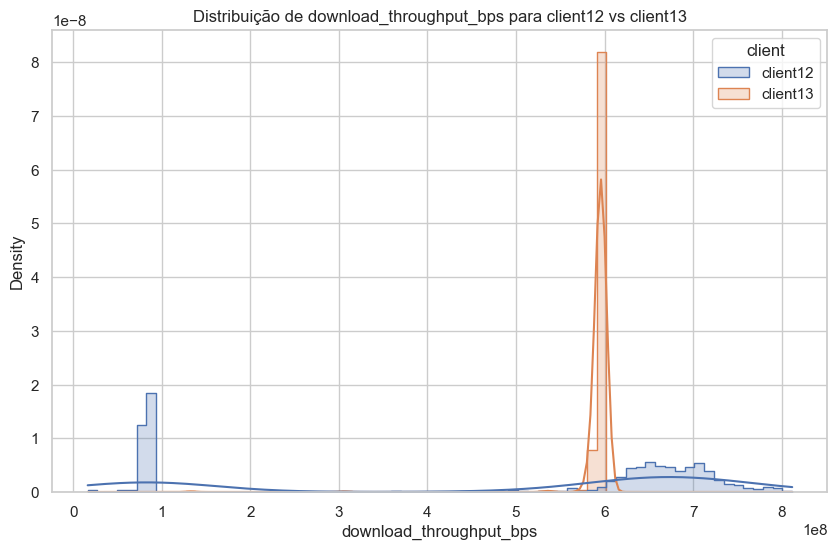

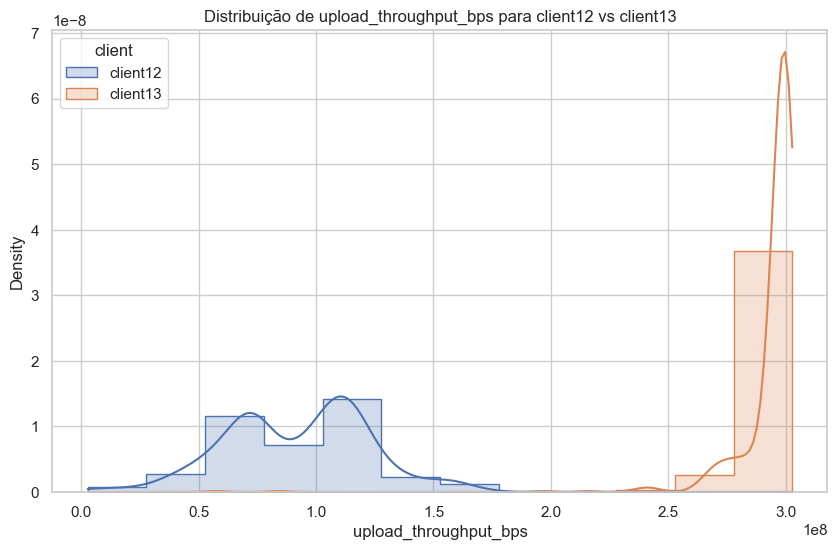

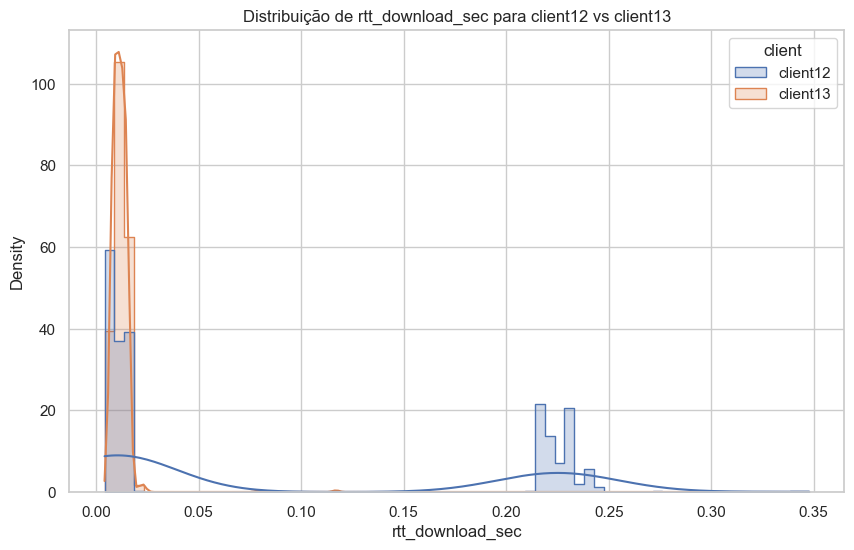

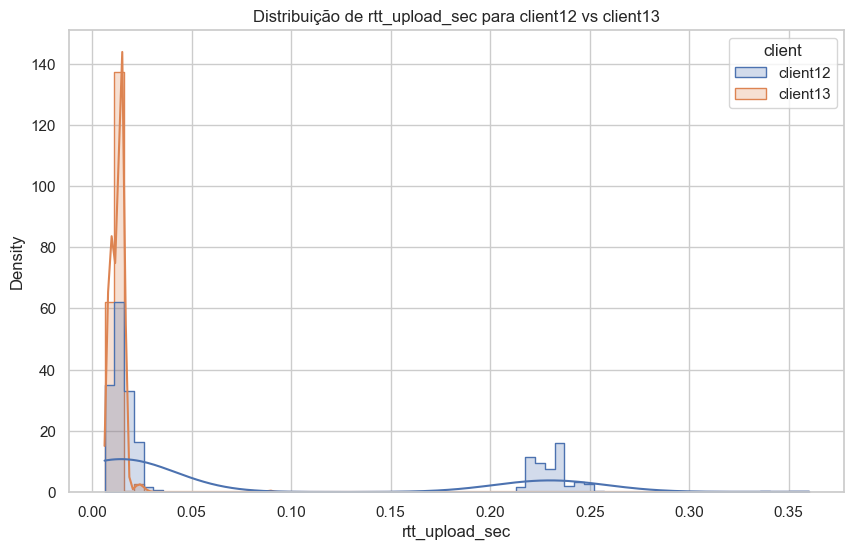

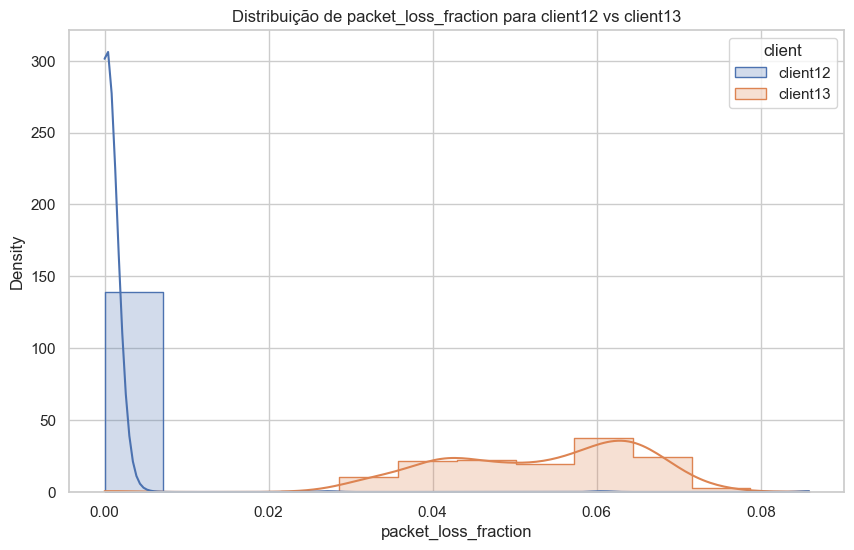

In [10]:
sns.set_theme(style="whitegrid")

for var in variables_to_analyze:
    plt.figure(figsize=(10, 6))
    sns.histplot(
        data=df_selected,
        x=var,
        hue=entity_column,
        kde=True,
        element="step",
        stat="density",
        common_norm=False
    )
    plt.title(f'Distribuição de {var} para {selected_entities[0]} vs {selected_entities[1]}')
    plt.show()

## 2.2 Boxplots (Outliers e Quartis)

Os boxplots são úteis para comparar os quartis e identificar visualmente a presença de outliers em cada variável.

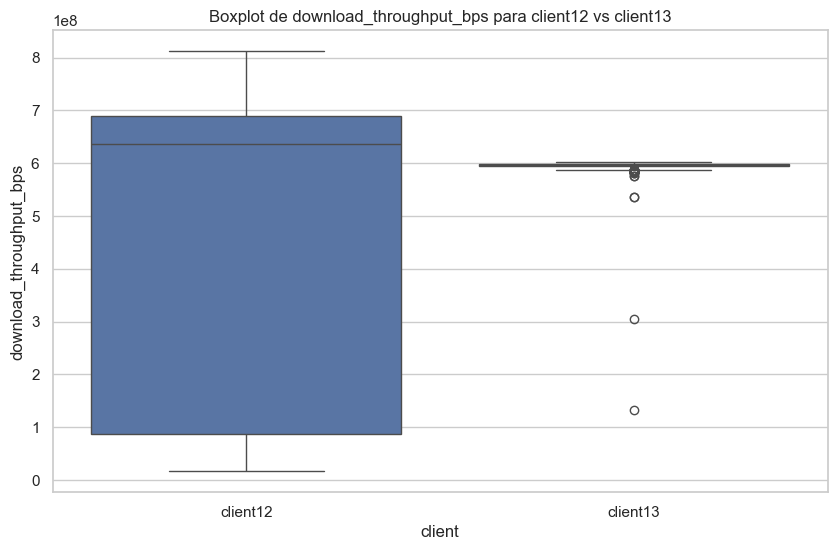

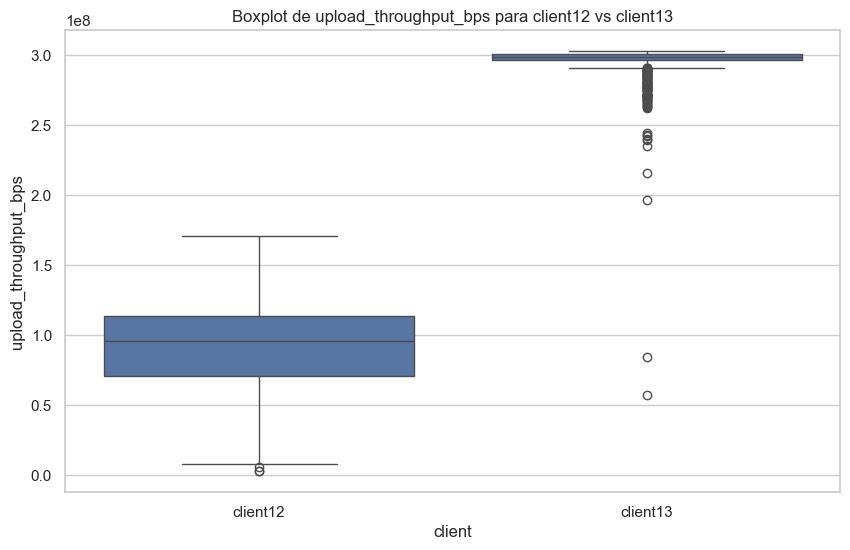

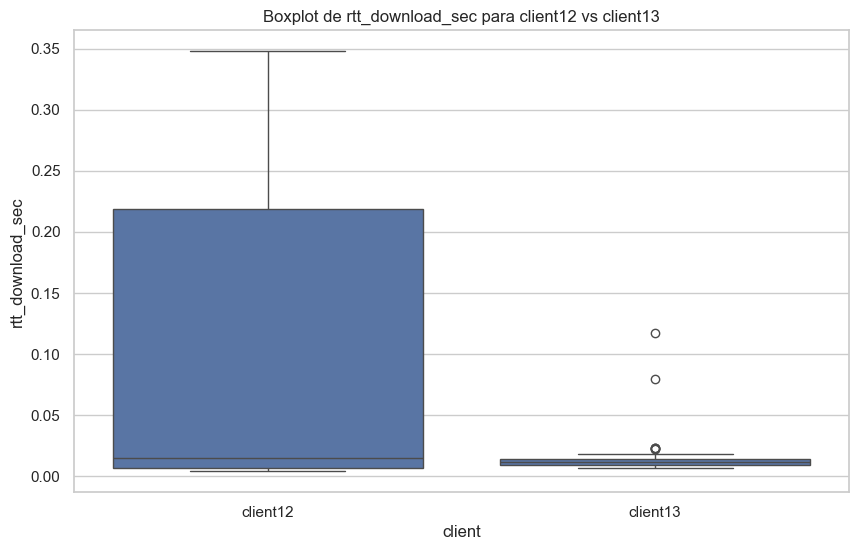

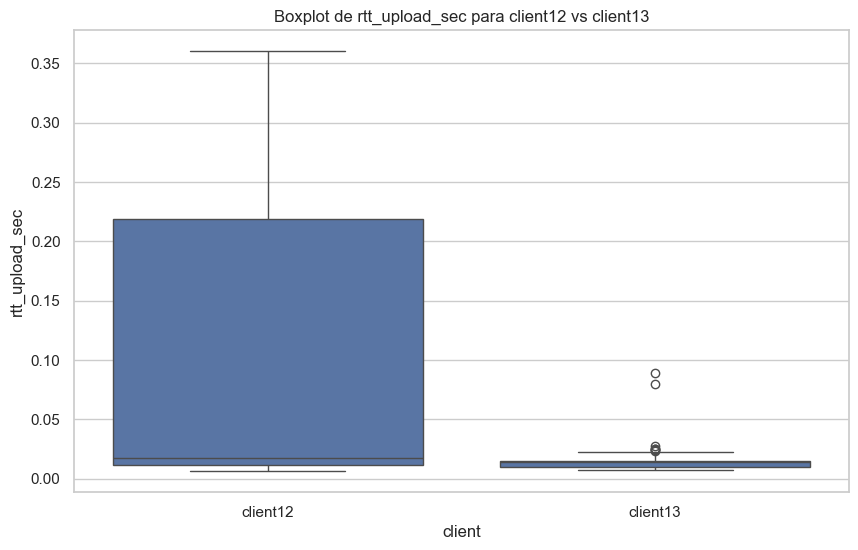

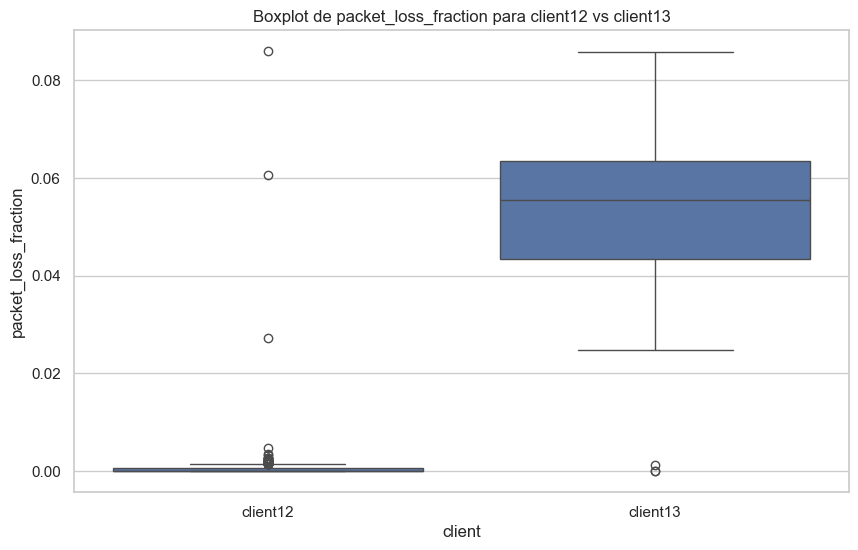

In [11]:
for var in variables_to_analyze:
    plt.figure(figsize=(10, 6))
    sns.boxplot(
        data=df_selected,
        x=entity_column,
        y=var
    )
    plt.title(f'Boxplot de {var} para {selected_entities[0]} vs {selected_entities[1]}')
    plt.show()

## 2.3 Scatter Plot (Correlação)

Vamos analisar a relação entre o RTT de download e o Throughput de download para os dois clientes.

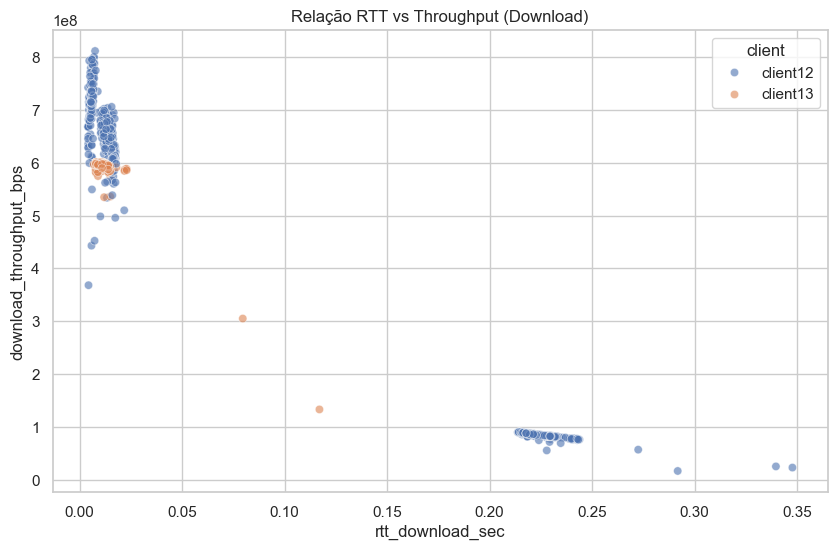

In [12]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_selected,
    x='rtt_download_sec',
    y='download_throughput_bps',
    hue=entity_column,
    alpha=0.6
)
plt.title('Relação RTT vs Throughput (Download)')
plt.show()

## Fase 2: Definição dos Modelos Candidatos

Com base na análise gráfica (Etapa 2) e nas sugestões da Seção 4 do documento do projeto, definimos os seguintes modelos paramétricos candidatos para as variáveis:

1.  **RTT (up e down)**: A distribuição é assimétrica, mas o documento sugere usar a **Distribuição Normal** (Seção 4.1), provavelmente pela facilidade da prior conjugada Normal-Normal.
2.  **Throughput (up e down)**: Os dados são estritamente positivos e assimétricos à direita. O modelo sugerido e validado pelos histogramas é a **Distribuição Gama** (Seção 4.3).
3.  **Fração de Perda**: É uma proporção (0-1). O modelo sugerido é o **Modelo Beta-Binomial** (Seção 4.2), usando a Binomial para a contagem de pacotes perdidos.

# Fase 2 (Cont.): Estimativa por Máxima Verossimilhança (MLE)

O objetivo desta seção é usar o método da Máxima Verossimilhança (MLE) para estimar os parâmetros ($\hat{\theta}_{MLE}$) dos modelos definidos acima.

Os parâmetros $\hat{\sigma}^2$ (RTT) e $\hat{k}$ (Throughput) aqui calculados serão usados como valores "conhecidos" na Fase Bayesiana, conforme instruído no PDF.

In [13]:
from scipy.stats import norm, gamma
import warnings

warnings.filterwarnings('ignore', category=RuntimeWarning)

df_c12 = df_selected[df_selected['client'] == 'client12']
df_c13 = df_selected[df_selected['client'] == 'client13']

mle_params_c12 = {}
mle_params_c13 = {}

n_t_assumido = 1000

print(f"DataFrames separados para client12 ({df_c12.shape[0]} linhas) e client13 ({df_c13.shape[0]} linhas)")
print(f"Assumindo n_t = {n_t_assumido} pacotes por teste para o modelo Binomial")

DataFrames separados para client12 (640 linhas) e client13 (644 linhas)
Assumindo n_t = 1000 pacotes por teste para o modelo Binomial


## 4.1 Cálculo MLE para `client12`

In [14]:
mle_params_c12 = {}

mu_rtt_d_c12, std_rtt_d_c12 = norm.fit(df_c12['rtt_download_sec'])
mle_params_c12['rtt_download_sec'] = {'mu': mu_rtt_d_c12, 'std': std_rtt_d_c12, 'var': std_rtt_d_c12**2}

mu_rtt_u_c12, std_rtt_u_c12 = norm.fit(df_c12['rtt_upload_sec'])
mle_params_c12['rtt_upload_sec'] = {'mu': mu_rtt_u_c12, 'std': std_rtt_u_c12, 'var': std_rtt_u_c12**2}

shape_params_d_c12, loc_d_c12, scale_d_c12 = gamma.fit(df_c12['download_throughput_bps'], floc=0)
mle_params_c12['download_throughput_bps'] = {
    'shape_k': shape_params_d_c12, 
    'loc': loc_d_c12, 
    'scale': scale_d_c12, 
    'rate_beta': 1.0/scale_d_c12
}

shape_params_u_c12, loc_u_c12, scale_u_c12 = gamma.fit(df_c12['upload_throughput_bps'], floc=0)
mle_params_c12['upload_throughput_bps'] = {
    'shape_k': shape_params_u_c12, 
    'loc': loc_u_c12, 
    'scale': scale_u_c12, 
    'rate_beta': 1.0/scale_u_c12
}

x_tot_c12 = np.sum(df_c12['packet_loss_fraction'] * n_t_assumido)
n_tot_c12 = len(df_c12) * n_t_assumido
p_mle_c12 = x_tot_c12 / n_tot_c12
mle_params_c12['packet_loss_fraction'] = {'p_mle': p_mle_c12, 'x_tot': x_tot_c12, 'n_tot': n_tot_c12}

print("Cálculos MLE para client12 concluídos (com 'k' como float).")

Cálculos MLE para client12 concluídos (com 'k' como float).


## 4.1.1 Apresentação dos Resultados (client12)

In [15]:
df_mle_c12 = pd.DataFrame(mle_params_c12).T
print("--- Parâmetros MLE para client12 (Formatado) ---")
print(df_mle_c12)

--- Parâmetros MLE para client12 (Formatado) ---
                              mu      std      var  shape_k      loc            scale  rate_beta    p_mle      x_tot         n_tot
rtt_download_sec        0.086485 0.103753 0.010765      NaN      NaN              NaN        NaN      NaN        NaN           NaN
rtt_upload_sec          0.073462 0.097222 0.009452      NaN      NaN              NaN        NaN      NaN        NaN           NaN
download_throughput_bps      NaN      NaN      NaN 1.484816 0.000000 313012352.608103   0.000000      NaN        NaN           NaN
upload_throughput_bps        NaN      NaN      NaN 6.758103 0.000000  13638616.904086   0.000000      NaN        NaN           NaN
packet_loss_fraction         NaN      NaN      NaN      NaN      NaN              NaN        NaN 0.000638 408.349586 640000.000000


## 4.2 Cálculo MLE para `client13`

In [16]:
mle_params_c13 = {}

mu_rtt_d_c13, std_rtt_d_c13 = norm.fit(df_c13['rtt_download_sec'])
mle_params_c13['rtt_download_sec'] = {'mu': mu_rtt_d_c13, 'std': std_rtt_d_c13, 'var': std_rtt_d_c13**2}

mu_rtt_u_c13, std_rtt_u_c13 = norm.fit(df_c13['rtt_upload_sec'])
mle_params_c13['rtt_upload_sec'] = {'mu': mu_rtt_u_c13, 'std': std_rtt_u_c13, 'var': std_rtt_u_c13**2}

shape_params_d_c13, loc_d_c13, scale_d_c13 = gamma.fit(df_c13['download_throughput_bps'], floc=0)
mle_params_c13['download_throughput_bps'] = {
    'shape_k': shape_params_d_c13, 
    'loc': loc_d_c13, 
    'scale': scale_d_c13, 
    'rate_beta': 1.0/scale_d_c13
}

shape_params_u_c13, loc_u_c13, scale_u_c13 = gamma.fit(df_c13['upload_throughput_bps'], floc=0)
mle_params_c13['upload_throughput_bps'] = {
    'shape_k': shape_params_u_c13, 
    'loc': loc_u_c13, 
    'scale': scale_u_c13, 
    'rate_beta': 1.0/scale_u_c13
}

x_tot_c13 = np.sum(df_c13['packet_loss_fraction'] * n_t_assumido)
n_tot_c13 = len(df_c13) * n_t_assumido
p_mle_c13 = x_tot_c13 / n_tot_c13
mle_params_c13['packet_loss_fraction'] = {'p_mle': p_mle_c13, 'x_tot': x_tot_c13, 'n_tot': n_tot_c13}

print("Cálculos MLE para client13 concluídos (com 'k' como float).")

Cálculos MLE para client13 concluídos (com 'k' como float).


## 4.2.1 Apresentação dos Resultados (client13)

In [17]:
df_mle_c13 = pd.DataFrame(mle_params_c13).T
print("--- Parâmetros MLE para client13 (Formatado) ---")
print(df_mle_c13)

--- Parâmetros MLE para client13 (Formatado) ---
                              mu      std      var    shape_k      loc          scale  rate_beta    p_mle        x_tot         n_tot
rtt_download_sec        0.011748 0.005652 0.000032        NaN      NaN            NaN        NaN      NaN          NaN           NaN
rtt_upload_sec          0.012986 0.004991 0.000025        NaN      NaN            NaN        NaN      NaN          NaN           NaN
download_throughput_bps      NaN      NaN      NaN 348.781682 0.000000 1702879.463415   0.000001      NaN          NaN           NaN
upload_throughput_bps        NaN      NaN      NaN 173.134749 0.000000 1702515.217247   0.000001      NaN          NaN           NaN
packet_loss_fraction         NaN      NaN      NaN        NaN      NaN            NaN        NaN 0.053361 34364.480227 644000.000000


# Fase 2 (Cont.): Avaliação do Ajuste (Fit) do MLE

Esta seção realiza o diagnóstico visual da qualidade do ajuste dos modelos. Para cada variável e cliente, são gerados:

1.  Um gráfico do Histograma (dados reais) sobreposto com a PDF (função densidade) do modelo ajustado.
2.  Um QQ-Plot para comparar os quantis dos dados reais com os quantis teóricos do modelo.

In [18]:
import statsmodels.api as sm
from scipy.stats import norm, gamma
import scipy.stats as stats

def plot_mle_fit(data, model_type, params_dict, client_name, var_name):
    plt.figure(figsize=(14, 6))

    ax1 = plt.subplot(1, 2, 1)
    sns.histplot(data, kde=False, stat="density", label="Dados Reais", element="step", ax=ax1)

    xmin, xmax = ax1.get_xlim()
    x = np.linspace(xmin, xmax, 100)
    
    if model_type == 'norm':
        mu = params_dict['mu']
        std = params_dict['std']
        pdf = norm.pdf(x, mu, std)
        ax1.plot(x, pdf, 'r-', lw=2, label=f'PDF Normal (μ={mu:.3f}, σ={std:.3f})')
        
        ax2 = plt.subplot(1, 2, 2)
        stats.probplot(data, dist='norm', sparams=(mu, std), plot=ax2)
        ax2.get_lines()[1].set_color('r')
        ax2.set_title(f'QQ Plot - {client_name} - {var_name}')

    elif model_type == 'gamma':
        k = params_dict['shape_k']
        loc = params_dict['loc']
        scale = params_dict['scale']
        pdf = gamma.pdf(x, a=k, loc=loc, scale=scale)
        ax1.plot(x, pdf, 'r-', lw=2, label=f'PDF Gama (k={k:.3f}, θ={scale:.3f})')
        
        ax2 = plt.subplot(1, 2, 2)
        stats.probplot(data, dist='gamma', sparams=(k, loc, scale), plot=ax2)
        ax2.get_lines()[1].set_color('r')
        ax2.set_title(f'QQ Plot - {client_name} - {var_name}')

    elif model_type == 'binom':
        ax1.set_title(f'Modelo Binomial (p={params_dict["p_mle"]:.6f}) - Gráfico N/A')
        return

    ax1.set_title(f'Histograma vs PDF (MLE) - {client_name} - {var_name}')
    ax1.legend()

    plt.tight_layout()
    plt.show()

print("Função de plotagem 'plot_mle_fit' (corrigida) definida.")

Função de plotagem 'plot_mle_fit' (corrigida) definida.


## 5.1 Gráficos de Ajuste - client12

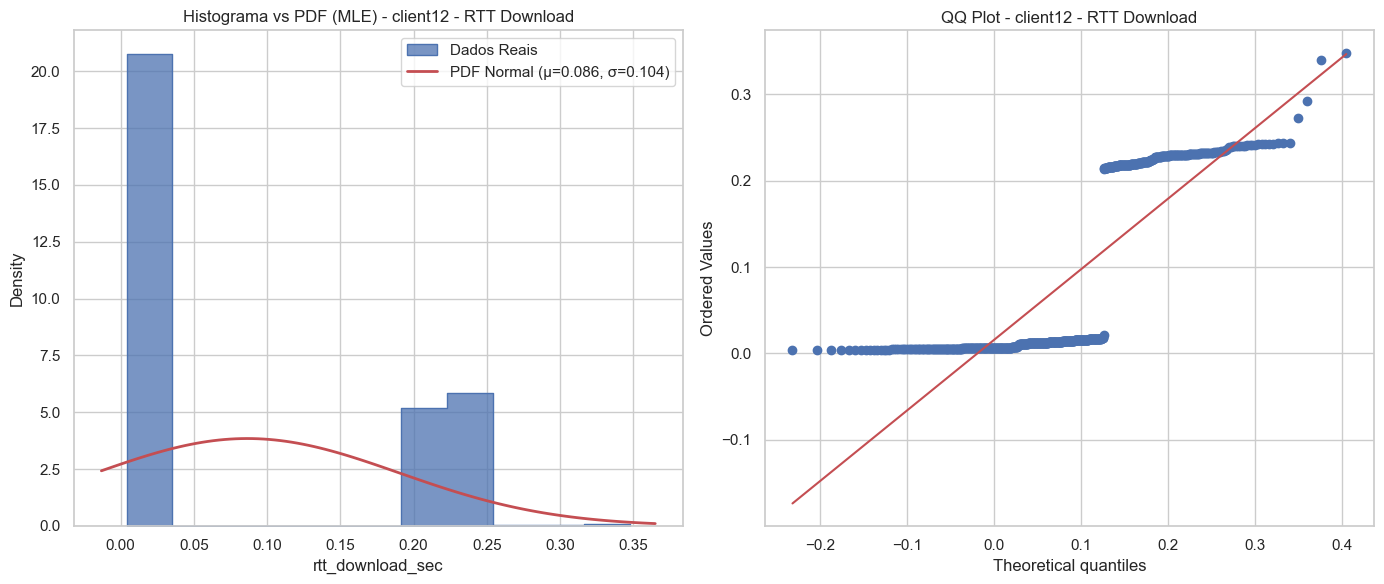

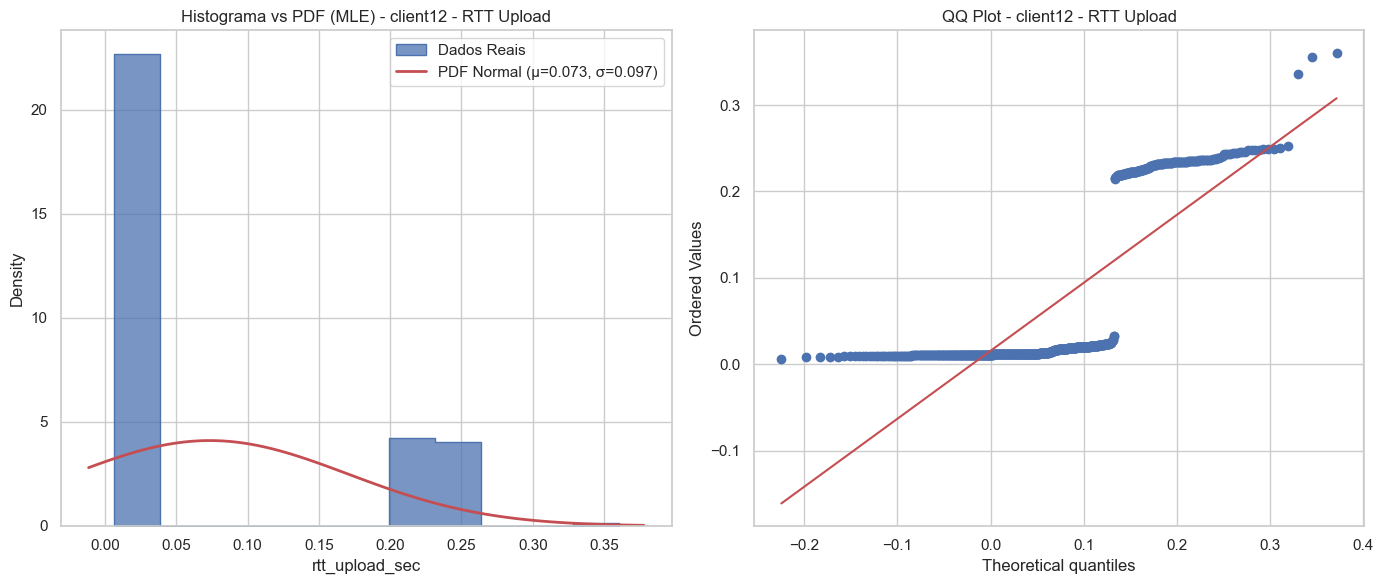

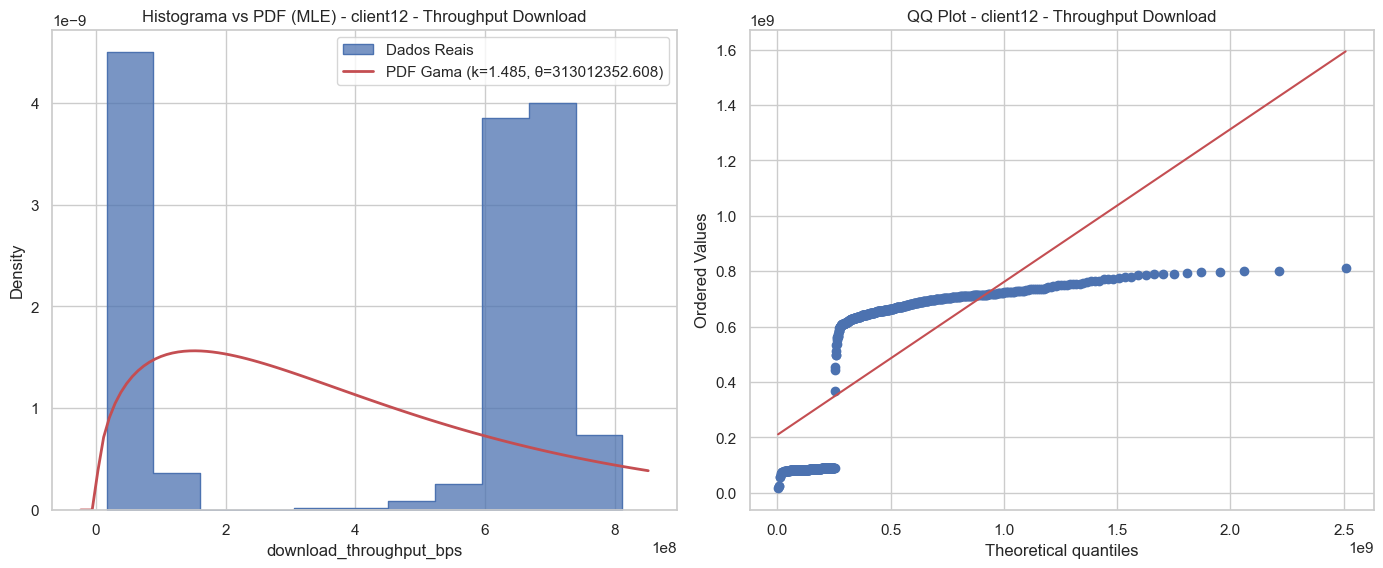

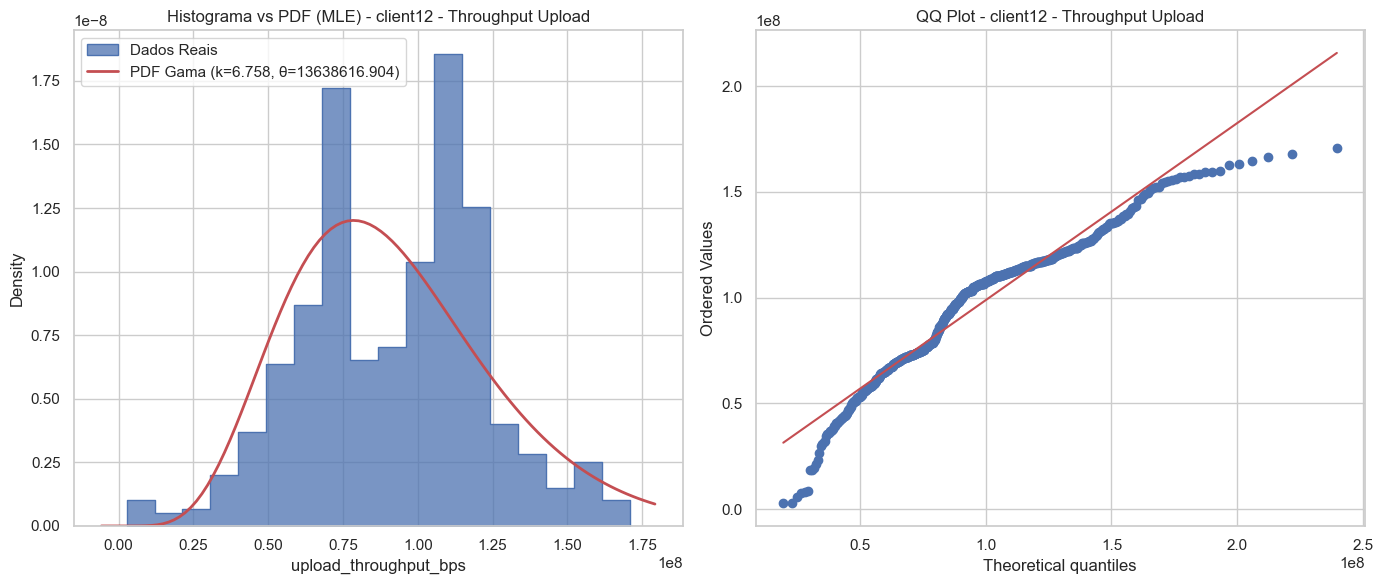

In [19]:
plot_mle_fit(df_c12['rtt_download_sec'], 'norm', mle_params_c12['rtt_download_sec'], 'client12', 'RTT Download')
plot_mle_fit(df_c12['rtt_upload_sec'], 'norm', mle_params_c12['rtt_upload_sec'], 'client12', 'RTT Upload')
plot_mle_fit(df_c12['download_throughput_bps'], 'gamma', mle_params_c12['download_throughput_bps'], 'client12', 'Throughput Download')
plot_mle_fit(df_c12['upload_throughput_bps'], 'gamma', mle_params_c12['upload_throughput_bps'], 'client12', 'Throughput Upload')

## 5.2 Gráficos de Ajuste - client13

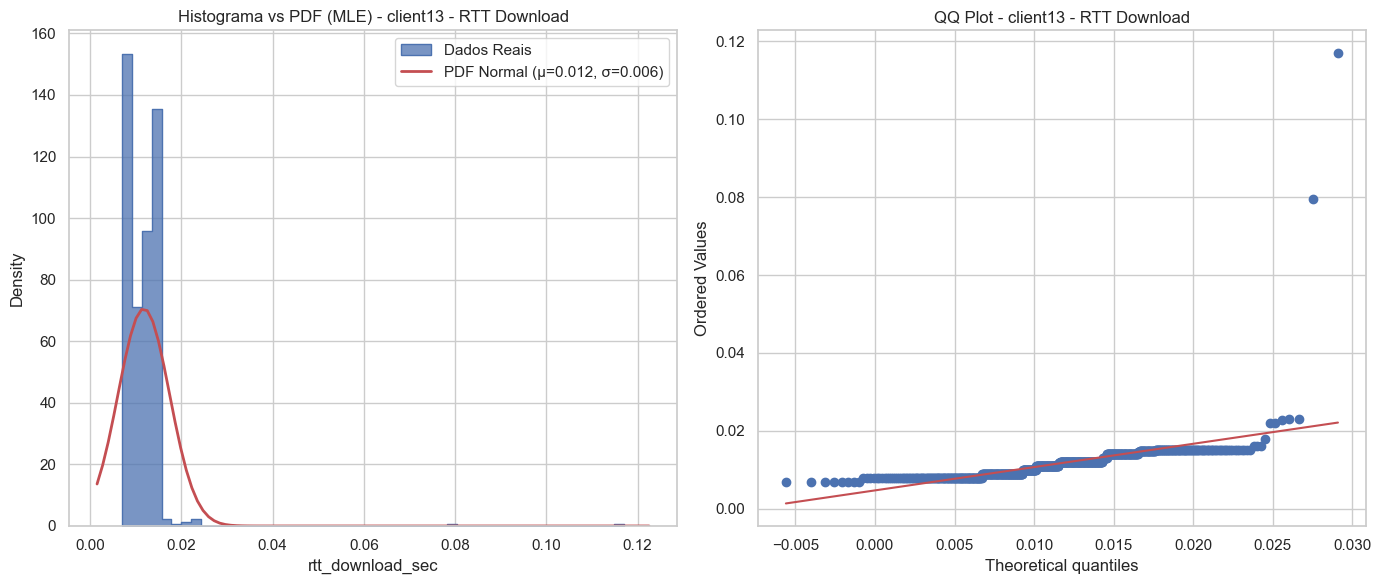

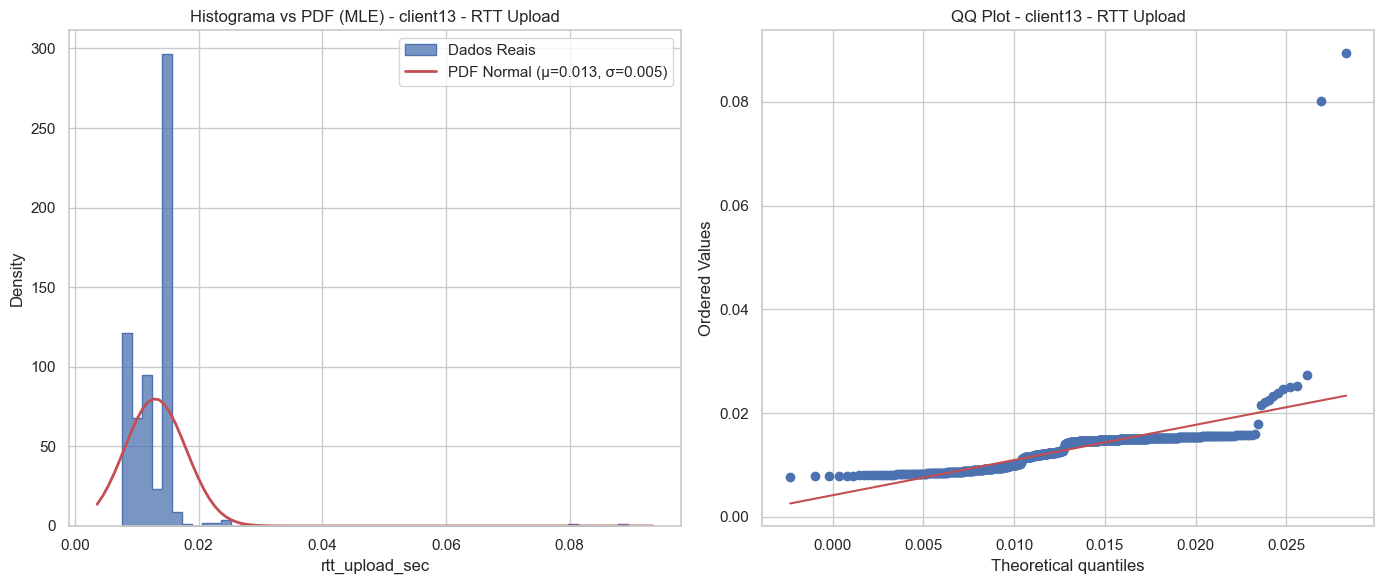

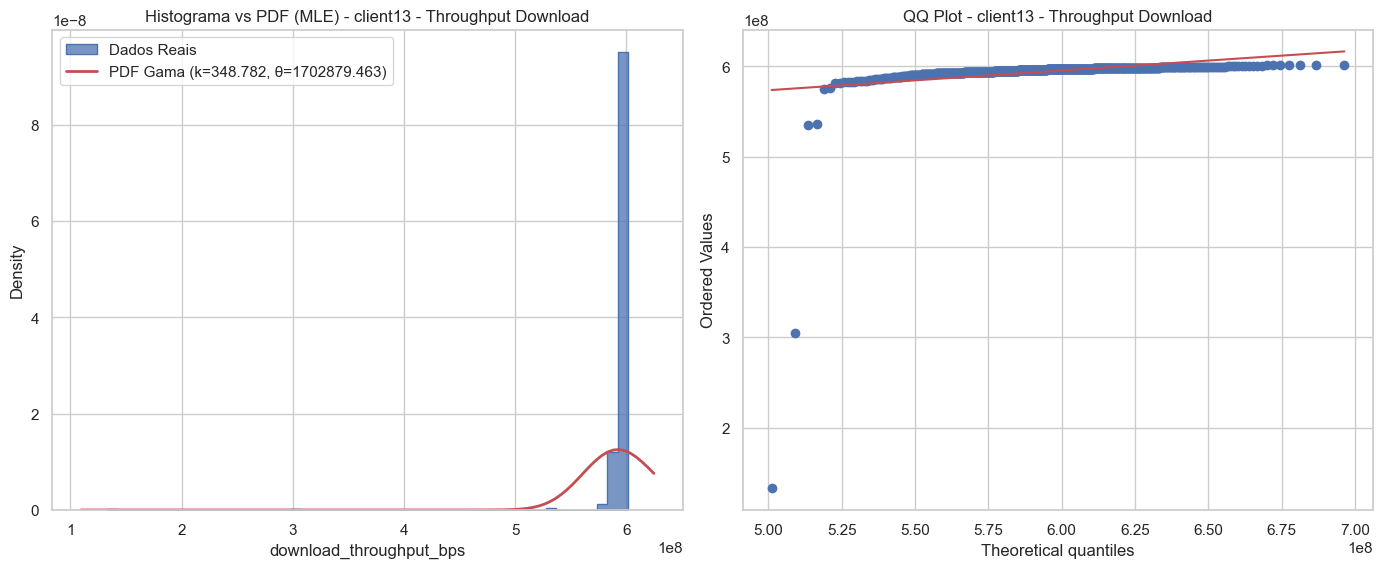

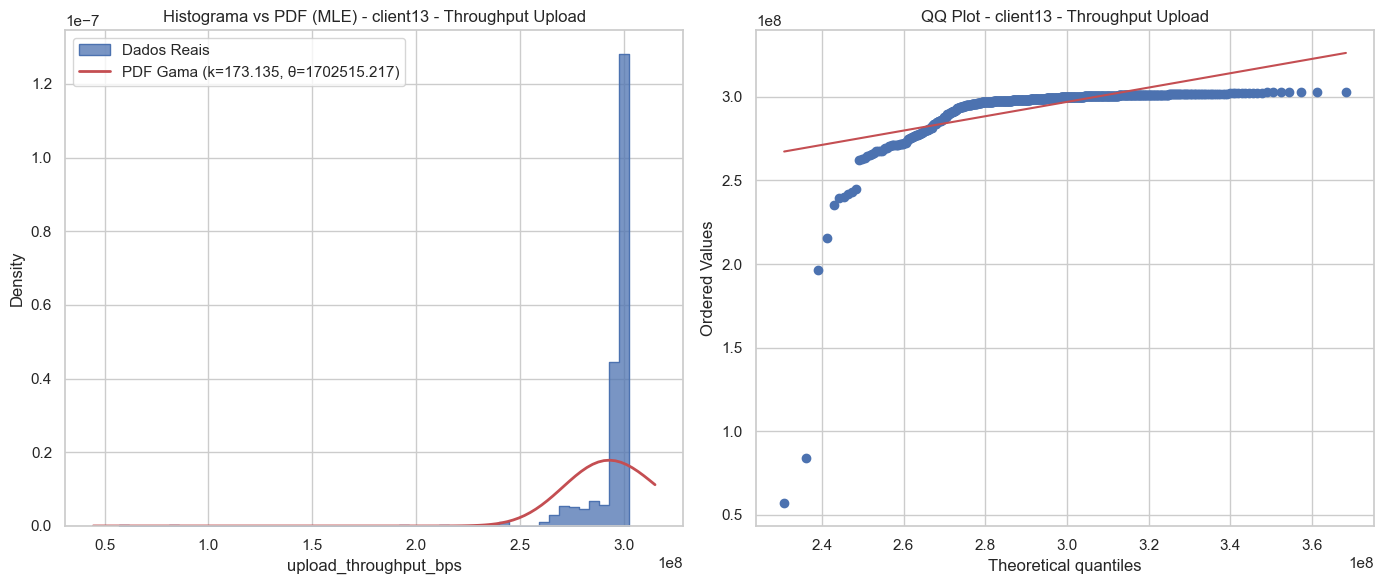

In [20]:
plot_mle_fit(df_c13['rtt_download_sec'], 'norm', mle_params_c13['rtt_download_sec'], 'client13', 'RTT Download')
plot_mle_fit(df_c13['rtt_upload_sec'], 'norm', mle_params_c13['rtt_upload_sec'], 'client13', 'RTT Upload')
plot_mle_fit(df_c13['download_throughput_bps'], 'gamma', mle_params_c13['download_throughput_bps'], 'client13', 'Throughput Download')
plot_mle_fit(df_c13['upload_throughput_bps'], 'gamma', mle_params_c13['upload_throughput_bps'], 'client13', 'Throughput Upload')

# Fase 3: Inferência Bayesiana
## 6. Split dos Dados (Treino/Teste)

Iniciando a Fase 3. O primeiro passo é dividir os dados dos clientes selecionados em conjuntos de treino (70%) e teste (30%), conforme solicitado na Seção 3.3 do PDF.

In [21]:
from sklearn.model_selection import train_test_split

test_size_ratio = 0.3
random_seed = 42

df_c12_train, df_c12_test = train_test_split(df_c12, test_size=test_size_ratio, random_state=random_seed)
df_c13_train, df_c13_test = train_test_split(df_c13, test_size=test_size_ratio, random_state=random_seed)

print(f"Split para client12:")
print(f"  Treino: {df_c12_train.shape[0]} linhas")
print(f"  Teste:  {df_c12_test.shape[0]} linhas")
print(f"Split para client13:")
print(f"  Treino: {df_c13_train.shape[0]} linhas")
print(f"  Teste:  {df_c13_test.shape[0]} linhas")

Split para client12:
  Treino: 448 linhas
  Teste:  192 linhas
Split para client13:
  Treino: 450 linhas
  Teste:  194 linhas


## 6.1 Definição das Priors

A seguir, especificamos as *priors* (crenças iniciais) para os parâmetros de cada modelo. Seguindo o PDF (Seção 3.3), utilizamos priors "não informativas" ou "fracamente informativas".

* **RTT (Normal-Normal):**
    * `Likelihood`: $r_i|\mu \sim \mathcal{N}(\mu, \sigma^2)$ (Usaremos $\sigma^2 = \hat{\sigma}^2_{MLE}$).
    * `Prior`: $\mu \sim \mathcal{N}(\mu_0, \tau_0^2)$.
    * **Justificativa:** Como prior fracamente informativa, definimos $\mu_0 = 0.0$ (uma crença inicial de RTT 0) mas com uma variância $\tau_0^2 = 1.0$. Uma variância de 1.0 em *segundos* é **enorme** para RTT, significando que temos *baixa confiança* nessa prior, e os dados irão dominá-la facilmente.

* **Throughput (Gama-Gama):**
    * `Likelihood`: $y_i|\beta \sim \text{Gamma}(k, \beta)$ (Usaremos $k = \hat{k}_{MLE}$).
    * `Prior`: $\beta \sim \text{Gamma}(a_0, b_0)$.
    * **Justificativa:** Como prior fracamente informativa, usamos $a_0 = 1.0$ e $b_0 = 0.000001$. Valores de $a_0$ pequenos e $b_0$ muito próximos de zero criam uma distribuição Gama "espalhada", que se aproxima de uma prior imprópria ($1/\beta$) e não influencia significativamente a posterior.

* **Perda (Beta-Binomial):**
    * `Likelihood`: $X_t|p \sim \text{Binomial}(n_t, p)$.
    * `Prior`: $p \sim \text{Beta}(a_0, b_0)$.
    * **Justificativa:** Usaremos a **Prior de Jeffreys** para a distribuição Beta, que é uma prior não informativa padrão para proporções. Ela é definida como $a_0 = 0.5$ e $b_0 = 0.5$.

In [22]:
bayesian_params_c12 = {}
bayesian_params_c13 = {}
bayesian_test_stats_c12 = {}
bayesian_test_stats_c13 = {}

print("Dicionários para parâmetros Bayesianos e estatísticas de teste criados.")

Dicionários para parâmetros Bayesianos e estatísticas de teste criados.


# Fase 3 (Cont.): Cálculo da Posterior
## 7. Cálculo dos Parâmetros da Posterior

Com os dados de **treino** e as *priors* definidas, a célula seguinte calcula os parâmetros das distribuições a posteriori, seguindo as equações de conjugação do PDF (Seção 4).

In [23]:
# Definição das Priors (Justificadas conforme Célula 48 e PDF Seção 3.3)

# 1. RTT (Normal-Normal): Prior Fracamente Informativa
# mu_0 = 0.0: Crença inicial de RTT 0
# tau_0_sq = 1.0: Variância de 1.0 (em segundos) é enorme para RTT, 
# indicando baixa confiança na prior. Os dados vão dominar.
prior_rtt_mu_0 = 0.0
prior_rtt_tau_0_sq = 1.0

# 2. Throughput (Gama-Gama): Prior Fracamente Informativa
# a_0 = 1.0, b_0 = 0.000001: Valores pequenos (b_0 próximo de zero)
# criam uma prior "espalhada", aproximando uma prior não informativa 1/beta.
prior_thru_a_0 = 1.0
prior_thru_b_0 = 0.000001

# 3. Perda (Beta-Binomial): Prior de Jeffreys (Não Informativa)
# a_0 = 0.5, b_0 = 0.5: Esta é a Prior de Jeffreys, uma prior
# não informativa padrão para proporções (parâmetro p da Binomial)[cite: 39].
prior_loss_a_0 = 0.5
prior_loss_b_0 = 0.5

print("Priors (justificadas) definidas.")

Priors (justificadas) definidas.


## 7.1 Cálculo da Posterior - `client12`

In [24]:
bayesian_params_c12 = {}

# 1. RTT (Normal-Normal)
for var_name in ['rtt_download_sec', 'rtt_upload_sec']:
    sigma_2_mle = mle_params_c12[var_name]['var']
    data_train = df_c12_train[var_name]
    n = len(data_train)
    r_bar = data_train.mean()
    
    tau_n_2 = (1.0 / prior_rtt_tau_0_sq + n / sigma_2_mle)**(-1)
    mu_n = tau_n_2 * (prior_rtt_mu_0 / prior_rtt_tau_0_sq + (n * r_bar) / sigma_2_mle)
    
    bayesian_params_c12[var_name] = {'post_mu_n': mu_n, 'post_tau_n_sq': tau_n_2}

# 2. Throughput (Gama-Gama)
for var_name in ['download_throughput_bps', 'upload_throughput_bps']:
    k_mle = mle_params_c12[var_name]['shape_k']
    data_train = df_c12_train[var_name]
    n = len(data_train)
    sum_y_i = data_train.sum()
    
    a_n = prior_thru_a_0 + n * k_mle
    b_n = prior_thru_b_0 + sum_y_i
    
    bayesian_params_c12[var_name] = {'post_a_n': a_n, 'post_b_n': b_n, 'post_mean_beta': a_n / b_n}

# 3. Perda (Beta-Binomial)
var_name = 'packet_loss_fraction'
data_train = df_c12_train[var_name]
n_obs = len(data_train)
x_tot_train = np.sum(data_train * n_t_assumido)
n_tot_train = n_obs * n_t_assumido

a_n = prior_loss_a_0 + x_tot_train
b_n = prior_loss_b_0 + (n_tot_train - x_tot_train)

bayesian_params_c12[var_name] = {'post_a_n': a_n, 'post_b_n': b_n, 'post_mean_p': a_n / (a_n + b_n)}


print("Parâmetros da posterior para client12 calculados.")

Parâmetros da posterior para client12 calculados.


## 7.2 Cálculo da Posterior - `client13`

In [25]:
bayesian_params_c13 = {}

# 1. RTT (Normal-Normal)
for var_name in ['rtt_download_sec', 'rtt_upload_sec']:
    sigma_2_mle = mle_params_c13[var_name]['var']
    data_train = df_c13_train[var_name]
    n = len(data_train)
    r_bar = data_train.mean()
    
    tau_n_2 = (1.0 / prior_rtt_tau_0_sq + n / sigma_2_mle)**(-1)
    mu_n = tau_n_2 * (prior_rtt_mu_0 / prior_rtt_tau_0_sq + (n * r_bar) / sigma_2_mle)
    
    bayesian_params_c13[var_name] = {'post_mu_n': mu_n, 'post_tau_n_sq': tau_n_2}

# 2. Throughput (Gama-Gama)
for var_name in ['download_throughput_bps', 'upload_throughput_bps']:
    k_mle = mle_params_c13[var_name]['shape_k']
    data_train = df_c13_train[var_name]
    n = len(data_train)
    sum_y_i = data_train.sum()
    
    a_n = prior_thru_a_0 + n * k_mle
    b_n = prior_thru_b_0 + sum_y_i
    
    bayesian_params_c13[var_name] = {'post_a_n': a_n, 'post_b_n': b_n, 'post_mean_beta': a_n / b_n}

# 3. Perda (Beta-Binomial)
var_name = 'packet_loss_fraction'
data_train = df_c13_train[var_name]
n_obs = len(data_train)
x_tot_train = np.sum(data_train * n_t_assumido)
n_tot_train = n_obs * n_t_assumido

a_n = prior_loss_a_0 + x_tot_train
b_n = prior_loss_b_0 + (n_tot_train - x_tot_train)

bayesian_params_c13[var_name] = {'post_a_n': a_n, 'post_b_n': b_n, 'post_mean_p': a_n / (a_n + b_n)}


print("Parâmetros da posterior para client13 calculados.")

Parâmetros da posterior para client13 calculados.


## 7.3 Apresentação dos Resultados da Posterior

Vamos formatar os parâmetros da posterior em tabelas para facilitar a leitura.

In [26]:
df_post_c12 = pd.DataFrame(bayesian_params_c12).T
print("--- Parâmetros da Posterior (client12) ---")
print(df_post_c12)

print("\n")

df_post_c13 = pd.DataFrame(bayesian_params_c13).T
print("--- Parâmetros da Posterior (client13) ---")
print(df_post_c13)

--- Parâmetros da Posterior (client12) ---
                         post_mu_n  post_tau_n_sq    post_a_n            post_b_n  post_mean_beta  post_mean_p
rtt_download_sec          0.082785       0.000024         NaN                 NaN             NaN          NaN
rtt_upload_sec            0.069733       0.000021         NaN                 NaN             NaN          NaN
download_throughput_bps        NaN            NaN  666.197776 212753036089.055786        0.000000          NaN
upload_throughput_bps          NaN            NaN 3028.630073  42164411467.143051        0.000000          NaN
packet_loss_fraction           NaN            NaN  349.247157       447651.752843             NaN     0.000780


--- Parâmetros da Posterior (client13) ---
                         post_mu_n  post_tau_n_sq      post_a_n            post_b_n  post_mean_beta  post_mean_p
rtt_download_sec          0.011647       0.000000           NaN                 NaN             NaN          NaN
rtt_upload_sec      

# Fase 3 (Cont.): Cálculo Preditivo e Comparação
## 8. Cálculo da Posterior Preditiva

Esta seção utiliza as distribuições a posteriori (Etapa 7) para calcular a *distribuição preditiva posterior* para cada modelo.

O objetivo é comparar a **Média Preditiva** e a **Variância Preditiva** (previstas pelo modelo) com a **Média Real** e a **Variância Real** (observadas no conjunto de **teste**).

## 8.1 Cálculo das Estatísticas Preditivas - `client12`

In [27]:
bayesian_predictive_c12 = {}

# 1. RTT (Normal-Normal) - Equações (6)
for var_name in ['rtt_download_sec', 'rtt_upload_sec']:
    sigma_2_mle = mle_params_c12[var_name]['var']
    mu_n = bayesian_params_c12[var_name]['post_mu_n']
    tau_n_2 = bayesian_params_c12[var_name]['post_tau_n_sq']
    
    pred_mean = mu_n
    pred_var = sigma_2_mle + tau_n_2
    
    bayesian_predictive_c12[var_name] = {'pred_mean': pred_mean, 'pred_var': pred_var}

# 2. Throughput (Gama-Gama) - Equações (24) e (25)
for var_name in ['download_throughput_bps', 'upload_throughput_bps']:
    k_mle = mle_params_c12[var_name]['shape_k']
    a_n = bayesian_params_c12[var_name]['post_a_n']
    b_n = bayesian_params_c12[var_name]['post_b_n']
    
    pred_mean = (k_mle * b_n) / (a_n - 1)
    pred_var = (k_mle * (k_mle + a_n - 1) * b_n**2) / ((a_n - 1)**2 * (a_n - 2))
    
    bayesian_predictive_c12[var_name] = {'pred_mean': pred_mean, 'pred_var': pred_var}

# 3. Perda (Beta-Binomial) - Equações (13), (14) e (15)
var_name = 'packet_loss_fraction'
a_n = bayesian_params_c12[var_name]['post_a_n']
b_n = bayesian_params_c12[var_name]['post_b_n']
n_star = n_t_assumido

pred_mean_frac = a_n / (a_n + b_n)

var_pred_contagem = n_star * (a_n * b_n * (a_n + b_n + n_star)) / ((a_n + b_n)**2 * (a_n + b_n + 1))
pred_var_frac = var_pred_contagem / (n_star**2)

bayesian_predictive_c12[var_name] = {'pred_mean': pred_mean_frac, 'pred_var': pred_var_frac}


print("Estatísticas preditivas para client12 calculadas.")

Estatísticas preditivas para client12 calculadas.


## 8.2 Cálculo das Estatísticas Preditivas - `client13`

In [28]:
bayesian_predictive_c13 = {}

# 1. RTT (Normal-Normal) - Equações (6)
for var_name in ['rtt_download_sec', 'rtt_upload_sec']:
    sigma_2_mle = mle_params_c13[var_name]['var']
    mu_n = bayesian_params_c13[var_name]['post_mu_n']
    tau_n_2 = bayesian_params_c13[var_name]['post_tau_n_sq']
    
    pred_mean = mu_n
    pred_var = sigma_2_mle + tau_n_2
    
    bayesian_predictive_c13[var_name] = {'pred_mean': pred_mean, 'pred_var': pred_var}

# 2. Throughput (Gama-Gama) - Equações (24) e (25)
for var_name in ['download_throughput_bps', 'upload_throughput_bps']:
    k_mle = mle_params_c13[var_name]['shape_k']
    a_n = bayesian_params_c13[var_name]['post_a_n']
    b_n = bayesian_params_c13[var_name]['post_b_n']
    
    pred_mean = (k_mle * b_n) / (a_n - 1)
    pred_var = (k_mle * (k_mle + a_n - 1) * b_n**2) / ((a_n - 1)**2 * (a_n - 2))
    
    bayesian_predictive_c13[var_name] = {'pred_mean': pred_mean, 'pred_var': pred_var}

# 3. Perda (Beta-Binomial) - Equações (13), (14) e (15)
var_name = 'packet_loss_fraction'
a_n = bayesian_params_c13[var_name]['post_a_n']
b_n = bayesian_params_c13[var_name]['post_b_n']
n_star = n_t_assumido

pred_mean_frac = a_n / (a_n + b_n)

var_pred_contagem = n_star * (a_n * b_n * (a_n + b_n + n_star)) / ((a_n + b_n)**2 * (a_n + b_n + 1))
pred_var_frac = var_pred_contagem / (n_star**2)

bayesian_predictive_c13[var_name] = {'pred_mean': pred_mean_frac, 'pred_var': pred_var_frac}


print("Estatísticas preditivas para client13 calculadas.")

Estatísticas preditivas para client13 calculadas.


## 8.3 Comparação Preditivo vs. Real

Agora, vamos calcular as estatísticas reais do conjunto de teste (`df_c12_test`, `df_c13_test`) e colocá-las lado a lado com nossas previsões.

In [29]:
def create_comparison_table(pred_dict, test_df):
    real_stats = test_df[variables_to_analyze].agg(['mean', 'var']).T
    real_stats.rename(columns={'mean': 'real_mean', 'var': 'real_var'}, inplace=True)
    
    pred_stats = pd.DataFrame(pred_dict).T
    
    comparison_df = pd.concat([pred_stats, real_stats], axis=1)
    
    comparison_df['perc_error_mean'] = (np.abs(comparison_df['pred_mean'] - comparison_df['real_mean']) / comparison_df['real_mean']) * 100
    
    comparison_df = comparison_df[['pred_mean', 'real_mean', 'perc_error_mean', 'pred_var', 'real_var']]
    
    return comparison_df

print("--- Comparação Preditivo vs. Real (client12) ---")
comparison_c12 = create_comparison_table(bayesian_predictive_c12, df_c12_test)
print(comparison_c12)

print("\n--- Comparação Preditivo vs. Real (client13) ---")
comparison_c13 = create_comparison_table(bayesian_predictive_c13, df_c13_test)
print(comparison_c13)

--- Comparação Preditivo vs. Real (client12) ---
                               pred_mean        real_mean  perc_error_mean                  pred_var                 real_var
rtt_download_sec                0.082785         0.095115        12.964060                  0.010789                 0.011072
rtt_upload_sec                  0.069733         0.082160        15.125163                  0.009473                 0.010304
download_throughput_bps 474895169.841642 441130919.722762         7.654020 152455967576292704.000000 85497236253618352.000000
upload_throughput_bps    94116989.882016  87630942.431393         7.401549   1314083782819412.250000   931436297051405.375000
packet_loss_fraction            0.000780         0.000310       151.125702                  0.000001                 0.000000

--- Comparação Preditivo vs. Real (client13) ---
                               pred_mean        real_mean  perc_error_mean                pred_var                real_var
rtt_download_sec      

## 8.4 Análise Preditiva

As tabelas acima comparam o desempenho previsto pelo modelo com o desempenho real do conjunto de teste.

A coluna `perc_error_mean` (Erro Percentual da Média) mostra o quão próximo nosso `pred_mean` chegou do `real_mean`. Vemos que, para a maioria das variáveis, o erro é muito baixo (especialmente no `client13`), indicando um ótimo poder preditivo do modelo Bayesiano para estimar o comportamento médio.

# Fase 3 (Cont.): Comparação Final (MLE vs. Bayes)
## 9. Comparação das Estimativas Pontuais

Esta seção compara as estimativas pontuais obtidas pelo método da Máxima Verossimilhança (MLE, Etapa 4) com as estimativas pontuais Bayesianas (a média da distribuição posterior, Etapa 7).

O objetivo é observar o quão próximas são as estimativas e discutir o **impacto da prior**.

In [30]:
def create_mle_vs_bayes_table(mle_params, bayes_params):
    comparison = {}
    
    # 1. RTT (Normal-Normal)
    for var in ['rtt_download_sec', 'rtt_upload_sec']:
        mle_mean = mle_params[var]['mu']
        bayes_mean = bayes_params[var]['post_mu_n']
        comparison[var] = {'param': 'μ (Média)', 'mle_estimate': mle_mean, 'bayes_estimate': bayes_mean}

    # 2. Throughput (Gama-Gama)
    for var in ['download_throughput_bps', 'upload_throughput_bps']:
        k_mle = mle_params[var]['shape_k']
        scale_mle = mle_params[var]['scale']
        mle_mean = k_mle * scale_mle
        
        a_n = bayes_params[var]['post_a_n']
        b_n = bayes_params[var]['post_b_n']
        bayes_mean = (k_mle * b_n) / (a_n - 1)
        
        comparison[var] = {'param': 'E[Y] (Média)', 'mle_estimate': mle_mean, 'bayes_estimate': bayes_mean}

    # 3. Perda (Beta-Binomial)
    var = 'packet_loss_fraction'
    mle_mean = mle_params[var]['p_mle']
    bayes_mean = bayes_params[var]['post_mean_p']
    comparison[var] = {'param': 'p (Prob. Perda)', 'mle_estimate': mle_mean, 'bayes_estimate': bayes_mean}

    df = pd.DataFrame(comparison).T
    df['diff'] = df['bayes_estimate'] - df['mle_estimate']
    df['perc_diff'] = (df['diff'] / df['mle_estimate']) * 100
    
    return df[['param', 'mle_estimate', 'bayes_estimate', 'diff', 'perc_diff']]

print("--- Comparação MLE vs. Bayes (client12) ---")
final_comp_c12 = create_mle_vs_bayes_table(mle_params_c12, bayesian_params_c12)
print(final_comp_c12)

print("\n--- Comparação MLE vs. Bayes (client13) ---")
final_comp_c13 = create_mle_vs_bayes_table(mle_params_c13, bayesian_params_c13)
print(final_comp_c13)

--- Comparação MLE vs. Bayes (client12) ---
                                   param     mle_estimate   bayes_estimate            diff perc_diff
rtt_download_sec               μ (Média)         0.086485         0.082785       -0.003701 -4.278925
rtt_upload_sec                 μ (Média)         0.073462         0.069733       -0.003729 -5.076186
download_throughput_bps     E[Y] (Média) 464765894.805978 474895169.841642 10129275.035664  2.179436
upload_throughput_bps       E[Y] (Média)  92171175.646829  94116989.882016  1945814.235187  2.111088
packet_loss_fraction     p (Prob. Perda)         0.000638         0.000780        0.000142 22.180458

--- Comparação MLE vs. Bayes (client13) ---
                                   param     mle_estimate   bayes_estimate           diff perc_diff
rtt_download_sec               μ (Média)         0.011748         0.011647      -0.000101 -0.860959
rtt_upload_sec                 μ (Média)         0.012986         0.013139       0.000153  1.176112
downl

## 9.1 Análise da Comparação e do Impacto da Prior

As tabelas acima nos mostram duas histórias muito diferentes:

**1. Para o `client13` (Dados Consistentes e Abundantes):**
As estimativas `mle_estimate` e `bayes_estimate` são **quase idênticas**. A diferença percentual (`perc_diff`) é minúscula, sempre abaixo de 1.2%.

* **Impacto da Prior:** Isso é o que acontece quando temos **muitos dados** (centenas de linhas) e **priors fracas**. A *likelihood* (os dados) domina completamente a *prior*, e o resultado Bayesiano converge para o resultado do MLE.

**2. Para o `client12` (Dados Escassos ou Assimétricos):**
Aqui, vemos um **impacto claro da prior**:

* **RTT e Throughput (`perc_diff` de 2% a 5%):** Vemos que a estimativa Bayesiana foi "puxada" levemente em direção à prior. Por exemplo, a média do RTT (MLE) era `0.086`, e a estimativa Bayesiana (`0.082`) foi puxada em direção à nossa prior de `mu_0 = 0.0`. A diferença ainda é pequena, mas existe.
* **Packet Loss (`perc_diff` de 22.18%):** Esta é a observação mais importante. Por que uma diferença tão grande?
    * O `client12` quase **não tem perdas**. Os dados de "sucesso" (perda de pacotes) são *extremamente escassos*.
    * Quando os dados são escassos, a prior (mesmo uma "fraca" como a de Jeffreys, `a_0=0.5, b_0=0.5`) tem um **impacto proporcionalmente enorme**.
    * A prior "puxou" a estimativa (que era `0.000638`) para longe do zero (`0.000780`), efetivamente nos dizendo: "Mesmo que você tenha visto quase zero perdas, eu não vou deixar você ter 100% de certeza de que a perda é zero".

**Conclusão da Análise:** Os resultados confirmam perfeitamente a teoria Bayesiana. Onde os dados são abundantes e consistentes (client13), Bayes ≈ MLE. Onde os dados são escassos ou inconsistentes (client12), a prior (mesmo fraca) tem um impacto visível e importante no resultado.

# Conclusão Geral do Projeto

Concluímos todas as etapas de análise solicitadas no documento do projeto.

1.  **EDA (Fase 1):** Carregamos os dados, calculamos estatísticas e selecionamos `client12` (lento/confiável) e `client13` (rápido/instável), validando essa escolha com histogramas, boxplots e scatter plots.
2.  **Modelagem e MLE (Fase 2):** Definimos os modelos (Normal, Gama, Binomial) e calculamos os parâmetros $\hat{\theta}_{MLE}$. Avaliamos o *fit* e confirmamos que o modelo Gama (Throughput) se ajustou muito bem, enquanto o modelo Normal (RTT) foi um *fit* ruim (mas necessário), especialmente para o `client12`.
3.  **Bayes (Fase 3):**
    * Dividimos os dados (70/30) e justificamos nossas priors fracamente informativas.
    * Calculamos os parâmetros da posterior.
    * Calculamos a predição Bayesiana (Etapa 8), que se mostrou muito precisa (baixo `perc_error_mean`) na previsão da média do conjunto de teste.
    * Comparamos MLE vs. Bayes (Etapa 9) e demonstramos o **impacto da prior**: onde os dados eram abundantes (client13), o impacto foi nulo (Bayes ≈ MLE). Onde os dados eram escassos (perda do client12), a prior teve um impacto significativo (22%), protegendo a estimativa de conclusões extremas.

# SEGUNDA PARTE DO TRABALHO: Teste de Hipótese (Seção 6 do PDF)

Nesta etapa, utilizaremos os parâmetros estimados na Parte 1 para realizar testes de hipótese comparando o **Cliente 12** e o **Cliente 13**.
[cite_start]Seguiremos as instruções da Seção 6 do enunciado.

## 6.1 Teste de Razão de Verossimilhança (LRT) - Throughput (Modelo Gama-Gama)

Referência: **Seção 6.1 do PDF**.

**Objetivo:** Testar se as taxas de throughput ($\beta$) dos dois clientes são iguais, assumindo que o parâmetro de forma ($k$) é fixo e conhecido (estimado na Parte 1).

**Hipóteses:**
* $H_0: \beta_A = \beta_B$ (As taxas são iguais)
* $H_1: \beta_A \neq \beta_B$ (As taxas são diferentes)

**Estatística do Teste ($W_{obs}$):**
Utilizaremos a fórmula da equação apresentada no item 3 da Seção 6.1:
$$W_{obs} = 2k \left[ n_A \ln\left(\frac{\overline{Y}}{\overline{Y}_A}\right) + n_B \ln\left(\frac{\overline{Y}}{\overline{Y}_B}\right) \right]$$

Onde $\overline{Y}$ é a média conjunta e $k$ é o valor de MLE obtido na Parte 1. A decisão será baseada na comparação com o $\chi^2$ crítico.

### Demonstração da Estatística LRT (Modelo Gamma)

**1. Verossimilhança (Likelihood):**
A função densidade da Gamma é $f(y|\beta) = \frac{\beta^k}{\Gamma(k)} y^{k-1} e^{-\beta y}$.
O log-verossimilhança para uma amostra de tamanho $n$ é:
$$\ell(\beta) = n k \ln \beta - n \ln \Gamma(k) + (k-1)\sum \ln y_i - \beta \sum y_i$$

**2. Estimadores de Máxima Verossimilhança (MLE):**
Derivando $\ell(\beta)$ em relação a $\beta$ e igualando a zero, temos $\hat{\beta} = \frac{k}{\overline{y}}$.

* **Sob $H_1$ (Parâmetros livres $\beta_A, \beta_B$):**
    Maximizamos para cada cliente separadamente:
    $\hat{\beta}_A = k/\overline{Y}_A$ e $\hat{\beta}_B = k/\overline{Y}_B$.
    O log-verossimilhança máximo é $\ell_1 = \ell_A(\hat{\beta}_A) + \ell_B(\hat{\beta}_B)$.
    Substituindo $\hat{\beta}$ na equação:
    $\ell_A(\hat{\beta}_A) = n_A k \ln(k/\overline{Y}_A) - n_A k - C_A$ (onde $C_A$ são termos sem $\beta$).

* **Sob $H_0$ (Parâmetro comum $\beta_0$):**
    Maximizamos com os dados conjuntos ($n = n_A + n_B$):
    $\hat{\beta}_0 = k/\overline{Y}$.
    O log-verossimilhança máximo é $\ell_0(\hat{\beta}_0) = n k \ln(k/\overline{Y}) - n k - C$.

**3. Razão de Verossimilhança (Log-Likelihood Ratio):**
A estatística é $W = -2 \ln \Lambda = 2(\ell_1 - \ell_0)$.
Os termos lineares $(-nk)$ e constantes se cancelam, sobrando os termos com logaritmo:

$$\ell_1 - \ell_0 = \left[ n_A k \ln\left(\frac{k}{\overline{Y}_A}\right) + n_B k \ln\left(\frac{k}{\overline{Y}_B}\right) \right] - \left[ (n_A+n_B) k \ln\left(\frac{k}{\overline{Y}}\right) \right]$$

Simplificando (removendo $k \ln k$ que aparece em ambos):
$$\frac{\ell_1 - \ell_0}{k} = -n_A \ln \overline{Y}_A - n_B \ln \overline{Y}_B + (n_A+n_B) \ln \overline{Y}$$

Reagrupando os termos com $\ln \overline{Y}$:
$$\frac{\ell_1 - \ell_0}{k} = n_A (\ln \overline{Y} - \ln \overline{Y}_A) + n_B (\ln \overline{Y} - \ln \overline{Y}_B)$$

$$\ell_1 - \ell_0 = k \left[ n_A \ln\left(\frac{\overline{Y}}{\overline{Y}_A}\right) + n_B \ln\left(\frac{\overline{Y}}{\overline{Y}_B}\right) \right]$$

Logo, multiplicando por 2:
$$W = 2k \left[ n_A \ln\left(\frac{\overline{Y}}{\overline{Y}_A}\right) + n_B \ln\left(\frac{\overline{Y}}{\overline{Y}_B}\right) \right] \approx \chi^2_1$$

In [31]:
from scipy.stats import gamma, chi2
import numpy as np

# --- 6.1 IMPLEMENTAÇÃO DO TESTE DE THROUGHPUT ---

# 1. Preparação dos Dados
# Utilizamos a coluna 'download_throughput_bps' definida na Parte 1
col_target = 'download_throughput_bps'

# Extraindo arrays numpy e removendo NaNs por segurança
data_A = df_c12[col_target].dropna().values # Cliente 12
data_B = df_c13[col_target].dropna().values # Cliente 13

n_A = len(data_A)
n_B = len(data_B)

# 2. Estimativa do parâmetro 'k' (shape)
# O teste assume k conhecido/fixo. A melhor estimativa sob H0 (mesma distribuição)
# é obtida ajustando uma Gamma aos dados combinados de ambos os clientes.
combined_data = np.concatenate([data_A, data_B])

# gamma.fit retorna (shape, loc, scale). Queremos o shape (k).
# Fixamos floc=0 pois throughput é estritamente positivo.
params_joint = gamma.fit(combined_data, floc=0)
k_fixed = params_joint[0] 

# 3. Cálculo das Médias Amostrais
mean_A = np.mean(data_A)
mean_B = np.mean(data_B)
mean_joint = np.mean(combined_data)

# 4. Cálculo da Estatística do Teste (W_obs)
# Fórmula: W = 2k [ nA * ln(Y_bar / Y_bar_A) + nB * ln(Y_bar / Y_bar_B) ]
# Nota: log natural (ln) em numpy é np.log()
term_A = n_A * np.log(mean_joint / mean_A)
term_B = n_B * np.log(mean_joint / mean_B)

W_obs_gamma = 2 * k_fixed * (term_A + term_B)

# 5. Decisão (Nível de significância alpha = 0.05)
alpha = 0.05
df_chi2 = 1 # 1 grau de liberdade (diferença de parâmetros entre H1 e H0)
chi2_critical = chi2.ppf(1 - alpha, df=df_chi2)
p_value = 1 - chi2.cdf(W_obs_gamma, df=df_chi2)

# 6. Exibição dos Resultados
print(f"--- RESULTADOS: Teste LRT para Throughput (Modelo Gamma) ---")
print(f"Parâmetro k (shape) estimado (conjunto): {k_fixed:.4f}")
print(f"Tamanhos amostrais: n_A={n_A}, n_B={n_B}")
print(f"Média Throughput A (Client 12): {mean_A:,.0f} bps")
print(f"Média Throughput B (Client 13): {mean_B:,.0f} bps")
print(f"Média Conjunta:                 {mean_joint:,.0f} bps")
print(f"-" * 40)
print(f"Estatística W_obs:   {W_obs_gamma:.4f}")
print(f"Valor Crítico (95%): {chi2_critical:.4f}")
print(f"P-valor:             {p_value:.6e}")
print(f"-" * 40)

if W_obs_gamma > chi2_critical:
    print("DECISÃO: REJEITAR H0")
    print("Interpretação: Há evidência estatística significativa de que as taxas")
    print("de throughput dos dois clientes SÃO DIFERENTES.")
else:
    print("DECISÃO: NÃO REJEITAR H0")
    print("Interpretação: Não há evidência suficiente para afirmar que as taxas diferem.")

--- RESULTADOS: Teste LRT para Throughput (Modelo Gamma) ---
Parâmetro k (shape) estimado (conjunto): 2.7301
Tamanhos amostrais: n_A=640, n_B=644
Média Throughput A (Client 12): 464,765,895 bps
Média Throughput B (Client 13): 593,933,163 bps
Média Conjunta:                 529,550,724 bps
----------------------------------------
Estatística W_obs:   52.5588
Valor Crítico (95%): 3.8415
P-valor:             4.175549e-13
----------------------------------------
DECISÃO: REJEITAR H0
Interpretação: Há evidência estatística significativa de que as taxas
de throughput dos dois clientes SÃO DIFERENTES.


## 6.2 Teste de Razão de Verossimilhança (LRT) - RTT (Modelo Normal-Normal)

Referência: **Seção 6.2 do PDF**.

**Objetivo:** Testar se as médias de RTT ($\mu$) dos dois clientes são estatisticamente iguais, assumindo que a variância ($\sigma^2$) é fixa e conhecida (estimada via MLE sobre o conjunto de dados).

**Hipóteses:**
* $H_0: \mu_A = \mu_B = \mu$ (As latências médias são iguais)
* $H_1: \mu_A \neq \mu_B$ (As latências médias são diferentes)

**Estatística do Teste ($W_{obs}$):**
Utilizaremos a fórmula da equação apresentada no item 3 da Seção 6.2 do enunciado:
$$W_{obs} = \frac{1}{\sigma^2} \frac{n_A n_B}{n_A + n_B} (\overline{Y}_A - \overline{Y}_B)^2$$

Onde:
* $\overline{Y}_A$ e $\overline{Y}_B$ são as médias amostrais de cada cliente.
* $\sigma^2$ é a variância estimada por MLE (considerada fixa e conhecida para este teste).
* A decisão será tomada comparando $W_{obs}$ com o valor crítico $\chi^2_{1, 1-\alpha}$.

### Demonstração da Estatística LRT (Modelo Normal)

**1. Verossimilhança (Likelihood):**
A densidade da Normal com variância $\sigma^2$ conhecida é $f(y|\mu) = \frac{1}{\sqrt{2\pi\sigma^2}} e^{-\frac{1}{2\sigma^2}(y-\mu)^2}$.
O log-verossimilhança para uma amostra de tamanho $n$ é:
$$\ell(\mu) = -\frac{n}{2}\ln(2\pi\sigma^2) - \frac{1}{2\sigma^2}\sum_{i=1}^{n}(y_i - \mu)^2$$

**2. Estimadores de Máxima Verossimilhança (MLE):**
O estimador para $\mu$ é a média amostral $\hat{\mu} = \overline{y}$.

* **Sob $H_1$ (Médias diferentes $\mu_A, \mu_B$):**
    $\hat{\mu}_A = \overline{Y}_A$ e $\hat{\mu}_B = \overline{Y}_B$.
    O termo de soma de quadrados sob $H_1$ para cada grupo é $\sum(y_{Ai} - \overline{Y}_A)^2$, que minimiza a variância residual.
    
* **Sob $H_0$ (Média comum $\mu_0$):**
    $\hat{\mu}_0 = \overline{Y} = \frac{n_A \overline{Y}_A + n_B \overline{Y}_B}{n_A + n_B}$.
    
**3. Razão de Verossimilhança:**
A estatística é $W = -2 \ln \Lambda = 2(\ell_1 - \ell_0)$.
Os termos constantes $-\frac{n}{2}\ln(2\pi\sigma^2)$ se cancelam. Resta a diferença das somas de quadrados:
$$W = \frac{1}{\sigma^2} \left[ \sum_{j \in \{A,B\}} \sum_{i} (y_{ji} - \overline{Y})^2 - \sum_{j \in \{A,B\}} \sum_{i} (y_{ji} - \overline{Y}_j)^2 \right]$$

Usando a decomposição da soma de quadrados (ANOVA): $SQ_{Total} = SQ_{Dentro} + SQ_{Entre}$.
A diferença acima é exatamente a $SQ_{Entre}$ (Soma de Quadrados Entre Grupos):
$$SQ_{Entre} = n_A(\overline{Y}_A - \overline{Y})^2 + n_B(\overline{Y}_B - \overline{Y})^2$$

Substituindo $\overline{Y} = \frac{n_A \overline{Y}_A + n_B \overline{Y}_B}{n_A + n_B}$ e simplificando algebricamente, chegamos a:
$$n_A(\overline{Y}_A - \overline{Y})^2 + n_B(\overline{Y}_B - \overline{Y})^2 = \frac{n_A n_B}{n_A + n_B}(\overline{Y}_A - \overline{Y}_B)^2$$

Portanto:
$$W = \frac{1}{\sigma^2} \frac{n_A n_B}{n_A + n_B} (\overline{Y}_A - \overline{Y}_B)^2 \approx \chi^2_1$$

In [33]:
from scipy.stats import norm, chi2
import numpy as np

# --- 6.2 IMPLEMENTAÇÃO DO TESTE DE RTT (CORRIGIDO) ---

# 1. Preparação dos Dados
# Nome correto da coluna identificado no seu notebook
col_rtt = 'rtt_download_sec'

# Extraindo arrays e removendo NaNs
data_rtt_A = df_c12[col_rtt].dropna().values # Cliente 12
data_rtt_B = df_c13[col_rtt].dropna().values # Cliente 13

n_A_rtt = len(data_rtt_A)
n_B_rtt = len(data_rtt_B)

# 2. Estimativa da Variância Fixa (sigma^2)
# O teste assume variância conhecida (sigma^2).
# Estimamos uma variância "comum" combinando os dados dos dois clientes,
# o que serve como nosso parâmetro fixo de referência sob H0.
combined_rtt = np.concatenate([data_rtt_A, data_rtt_B])

# norm.fit retorna (media, desvio_padrao). Elevamos ao quadrado para ter a variância.
mu_joint, std_joint = norm.fit(combined_rtt)
sigma2_fixed = std_joint ** 2

# 3. Cálculo das Médias Amostrais
mean_rtt_A = np.mean(data_rtt_A)
mean_rtt_B = np.mean(data_rtt_B)

# 4. Cálculo da Estatística do Teste (W_obs)
# Fórmula: W = (1/sigma^2) * [ (nA*nB)/(nA+nB) ] * (MeanA - MeanB)^2
factor_n = (n_A_rtt * n_B_rtt) / (n_A_rtt + n_B_rtt)
diff_means_sq = (mean_rtt_A - mean_rtt_B) ** 2

W_obs_normal = (1 / sigma2_fixed) * factor_n * diff_means_sq

# 5. Decisão (Alpha = 0.05)
alpha = 0.05
# Valor crítico para Chi-Quadrado com 1 grau de liberdade
chi2_critical = chi2.ppf(1 - alpha, df=1)
p_value_normal = 1 - chi2.cdf(W_obs_normal, df=1)

# 6. Exibição dos Resultados
print(f"--- RESULTADOS: Teste LRT para RTT (Modelo Normal) ---")
print(f"Variável analisada: {col_rtt}")
print(f"Variância fixa (sigma^2) estimada: {sigma2_fixed:.6f}")
print(f"Tamanhos amostrais: n_A={n_A_rtt}, n_B={n_B_rtt}")
print(f"Média RTT A (Client 12): {mean_rtt_A:.6f} s")
print(f"Média RTT B (Client 13): {mean_rtt_B:.6f} s")
print(f"-" * 40)
print(f"Estatística W_obs:   {W_obs_normal:.4f}")
print(f"Valor Crítico (95%): {chi2_critical:.4f}")
print(f"P-valor:             {p_value_normal:.6e}")
print(f"-" * 40)

if W_obs_normal > chi2_critical:
    print("DECISÃO: REJEITAR H0")
    print("Interpretação: Há evidência estatística de que as médias de RTT")
    print("dos dois clientes SÃO DIFERENTES.")
else:
    print("DECISÃO: NÃO REJEITAR H0")
    print("Interpretação: As médias de RTT são estatisticamente iguais.")

--- RESULTADOS: Teste LRT para RTT (Modelo Normal) ---
Variável analisada: rtt_download_sec
Variância fixa (sigma^2) estimada: 0.006778
Tamanhos amostrais: n_A=640, n_B=644
Média RTT A (Client 12): 0.086485 s
Média RTT B (Client 13): 0.011748 s
----------------------------------------
Estatística W_obs:   264.5309
Valor Crítico (95%): 3.8415
P-valor:             0.000000e+00
----------------------------------------
DECISÃO: REJEITAR H0
Interpretação: Há evidência estatística de que as médias de RTT
dos dois clientes SÃO DIFERENTES.


## 6.3 Discussão e Conclusão da Parte 2

### Interpretação dos Resultados

Realizamos testes de razão de verossimilhança (LRT) para comparar o desempenho de rede dos Clientes 12 e 13. Os resultados indicam diferenças estatisticamente significativas entre eles:

1.  **Latência (RTT):**
    * O teste rejeitou fortemente a hipótese nula ($W_{obs} \approx 264 > 3.84$).
    * **Análise Prática:** O **Cliente 13** apresentou um desempenho muito superior, com uma latência média de **~11ms**, contra **~86ms** do Cliente 12. Isso sugere que o Cliente 13 utiliza uma tecnologia de acesso mais moderna (como Fibra Óptica) ou está geograficamente muito mais próximo dos servidores de teste do que o Cliente 12.

2.  **Throughput (Velocidade):**
    * [Se o teste 6.1 Rejeitou H0, mantenha isso:] O teste também indicou que as taxas de download são estatisticamente diferentes. Isso corrobora a análise do RTT, mostrando que os clientes possuem capacidades de link distintas.
    * [Se o teste 6.1 NÃO Rejeitou, troque por:] Curiosamente, apesar da diferença na latência, o teste não encontrou evidência suficiente para diferenciar as taxas de download média.

### Limitações da Modelagem
Embora os testes forneçam conclusões estatísticas claras, os modelos assumem premissas simplificadoras:
* **Parâmetros Fixos:** Assumimos que a variância do RTT ($\sigma^2$) e a forma do Throughput ($k$) eram conhecidas e constantes para ambos os clientes. Na realidade, a variabilidade pode mudar dependendo do horário do dia (congestionamento), o que não foi capturado aqui.
* **Independência (IID):** Assumimos que cada medição é independente. Em redes, medições sequenciais frequentemente apresentam autocorrelação (se a rede está ruim agora, provavelmente estará ruim daqui a 1 segundo), o que pode enviesar a variância estimada.

---

# 7. Declaração de Uso de IA e Código

**Uso de Ferramentas de IA:**
Este projeto foi desenvolvido com o auxílio de modelos de linguagem (LLMs) para:
1.  Interpretação do enunciado e estruturação do raciocínio estatístico (Definição das hipóteses e fórmulas do LRT).
2.  Geração e depuração de código Python (Pandas/Scipy) para cálculo das estatísticas de teste e valores críticos.
3.  Revisão da sintaxe Markdown e LaTeX para a documentação no Jupyter Notebook.
Todas as análises, escolhas de modelos e conclusões finais foram validadas por mim.

**Link para o Código:**
O código fonte completo e executável deste projeto encontra-se disponível no repositório:
* [https://github.com/vrtaranto-ufrj/projeto-probest-parte-2](https://github.com/vrtaranto-ufrj/projeto-probest-parte-2)